In [ ]:
# =============================================================================
# CELDA 1: INSTALACIÓN DE LIBRERÍAS
# =============================================================================
!pip install EntropyHub
!pip install scikit-posthocs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 require

In [ ]:
# =============================================================================
# CELDA 2: IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import EntropyHub as EH
import os
import warnings
from scipy import stats
from scipy.stats import kruskal, shapiro, levene, mannwhitneyu
import scikit_posthocs as sp
from itertools import combinations
from google.colab import drive

warnings.filterwarnings('ignore')

# Configuración global de matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Montar Google Drive
drive.mount('/content/drive')

print("✅ Todas las librerías importadas correctamente")

Mounted at /content/drive
✅ Todas las librerías importadas correctamente


In [ ]:
# =============================================================================
# CELDA 3: CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# =============================================================================

# --- Rutas ---
BASE_PATH = '/content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Datos3'
RESULTS_PATH = '/content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Resultados3'

# Crear carpetas de resultados
os.makedirs(os.path.join(RESULTS_PATH, 'figuras'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, 'tablas'), exist_ok=True)

# --- Estructura de datos ---
GROUPS = {
    'Sleep': {
        'folder': 'Sleep',
        'files': [f'sleep{i}.txt' for i in range(1, 9)],
        'color': '#3498db',
        'color_light': '#85c1e9',
        'marker': 'o',
        'description': 'Sueño (inconsciente)'
    },
    'TaiChi': {
        'folder': 'TaiChi',
        'files': [f'taichi{i}.txt' for i in range(1, 5)],
        'color': '#e74c3c',
        'color_light': '#f1948a',
        'marker': 's',
        'description': 'Tai Chi (consciente)'
    },
    'Yoga': {
        'folder': 'Yoga',
        'files': [f'yoga{i}.txt' for i in range(1, 5)],
        'color': '#2ecc71',
        'color_light': '#82e0aa',
        'marker': '^',
        'description': 'Yoga Kundalini (consciente)'
    }
}

# --- Parámetros de entropía ---
SAMPEN_M = 2       # Dimensión embedding para SampEn
SAMPEN_R = 0.2     # Tolerancia (proporción de std)
PERMEN_M = 3       # Orden para PermEn
PERMEN_TAU = 1     # Delay temporal
ALPHA = 0.05       # Nivel de significancia

# --- Orden de grupos para gráficas ---
GROUP_ORDER = ['Sleep', 'TaiChi', 'Yoga']

print("=" * 65)
print("  ANÁLISIS DE ENTROPÍA - ECG LATIDO A LATIDO")
print("=" * 65)
print(f"\n📁 Datos:      {BASE_PATH}")
print(f"📁 Resultados: {RESULTS_PATH}")
print(f"\n⚙️  SampEn: m={SAMPEN_M}, r={SAMPEN_R}·std")
print(f"⚙️  PermEn: m={PERMEN_M}, τ={PERMEN_TAU}")
print(f"⚙️  α = {ALPHA}")
print(f"\n📊 Grupos:")
for g, info in GROUPS.items():
    print(f"   • {g}: {len(info['files'])} archivos - {info['description']}")

  ANÁLISIS DE ENTROPÍA - ECG LATIDO A LATIDO

📁 Datos:      /content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Datos3
📁 Resultados: /content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Resultados3

⚙️  SampEn: m=2, r=0.2·std
⚙️  PermEn: m=3, τ=1
⚙️  α = 0.05

📊 Grupos:
   • Sleep: 8 archivos - Sueño (inconsciente)
   • TaiChi: 4 archivos - Tai Chi (consciente)
   • Yoga: 4 archivos - Yoga Kundalini (consciente)


In [ ]:
# =============================================================================
# CELDA 4: CARGA DE DATOS ECG
# =============================================================================

ecg_data = {}

print("=" * 65)
print("  CARGA DE DATOS")
print("=" * 65)

for group_name, group_info in GROUPS.items():
    ecg_data[group_name] = {}
    folder_path = os.path.join(BASE_PATH, group_info['folder'])

    print(f"\n📂 {group_name} ({folder_path}):")

    if not os.path.exists(folder_path):
        print(f"   ⚠️ CARPETA NO ENCONTRADA")
        continue

    for filename in group_info['files']:
        filepath = os.path.join(folder_path, filename)

        if os.path.exists(filepath):
            try:
                signal = np.loadtxt(filepath)
                if signal.ndim > 1:
                    signal = signal[:, 0]
                signal = signal[~np.isnan(signal)]

                ecg_data[group_name][filename] = signal
                print(f"   ✅ {filename}: {len(signal)} latidos | "
                      f"Media={np.mean(signal):.4f} | Std={np.std(signal):.4f}")
            except Exception as e:
                print(f"   ❌ Error en {filename}: {e}")
        else:
            print(f"   ⚠️ No encontrado: {filename}")

# Resumen
print("\n" + "-" * 40)
print("📋 RESUMEN:")
total = 0
for g in GROUPS:
    n = len(ecg_data.get(g, {}))
    total += n
    print(f"   {g}: {n} archivos cargados")
print(f"   TOTAL: {total} archivos")

  CARGA DE DATOS

📂 Sleep (/content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Datos3/Sleep):
   ✅ sleep1.txt: 864 latidos | Media=1039.5862 | Std=50.4530
   ✅ sleep2.txt: 906 latidos | Media=992.1551 | Std=42.1496
   ✅ sleep3.txt: 841 latidos | Media=1068.5850 | Std=42.9569
   ✅ sleep4.txt: 963 latidos | Media=934.0213 | Std=41.7608
   ✅ sleep5.txt: 661 latidos | Media=1359.4402 | Std=69.4918
   ✅ sleep6.txt: 830 latidos | Media=1082.3886 | Std=95.6961
   ✅ sleep7.txt: 1266 latidos | Media=710.2705 | Std=23.8180
   ✅ sleep8.txt: 899 latidos | Media=999.8081 | Std=33.5932

📂 TaiChi (/content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Datos3/TaiChi):
   ✅ taichi1.txt: 4034 latidos | Media=824.6760 | Std=94.7456
   ✅ taichi2.txt: 3599 latidos | Media=738.7744 | Std=53.2358
   ✅ taichi3.txt: 3767 latidos | Media=810.4200 | Std=78.9481
   ✅ taichi4.txt: 3150 latidos | Media=826.8594 | Std=89.0481

📂 Yoga (/content/drive/MyDrive/8vo_LiFTA/Análisis_Numérico/AN2026/Datos3/Yoga):
 

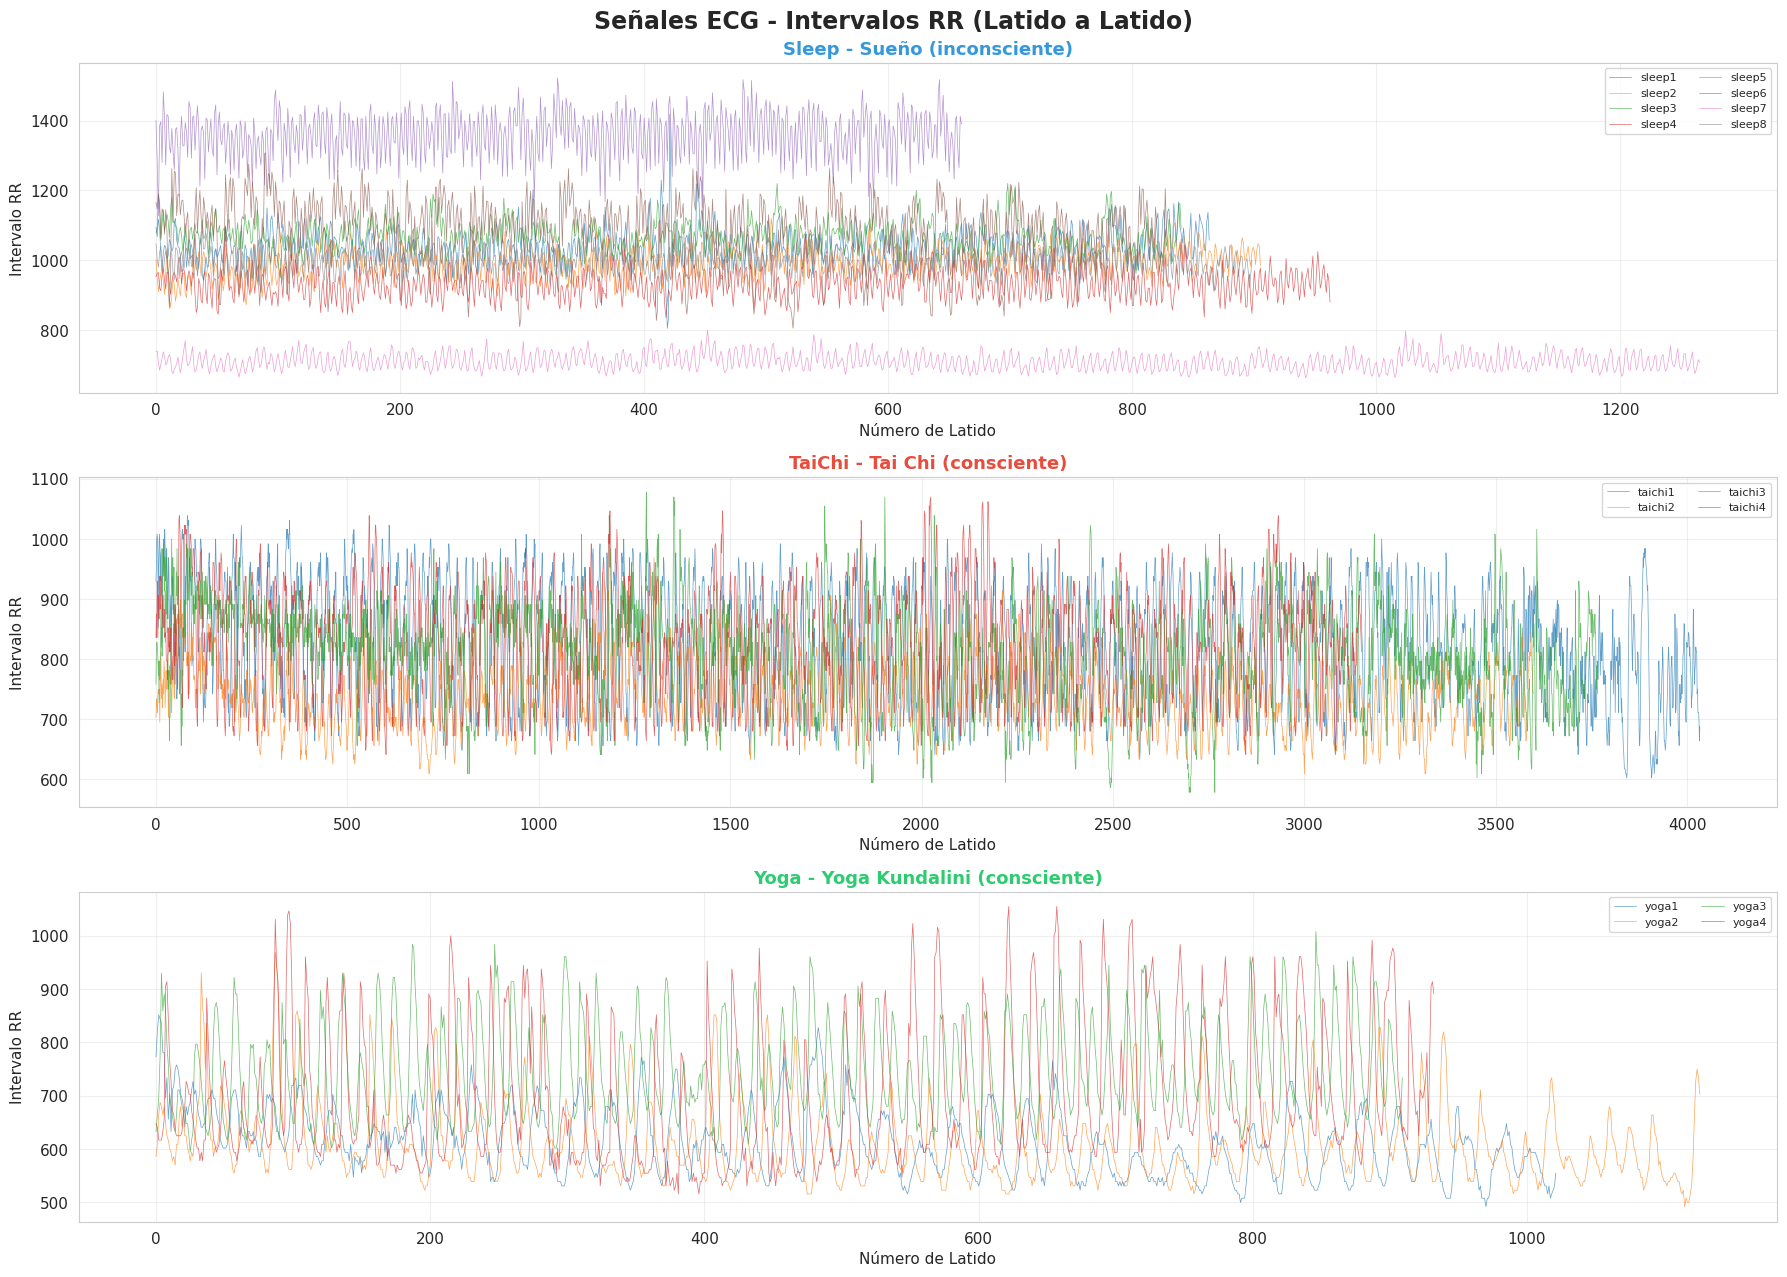

✅ Figura guardada: 01_senales_crudas.png


In [ ]:
# =============================================================================
# CELDA 5: VISUALIZACIÓN DE SEÑALES CRUDAS
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 13))
fig.suptitle('Señales ECG - Intervalos RR (Latido a Latido)',
             fontsize=17, fontweight='bold', y=0.98)

for idx, (group_name, group_info) in enumerate(GROUPS.items()):
    ax = axes[idx]

    if group_name in ecg_data:
        for filename, signal in ecg_data[group_name].items():
            ax.plot(signal, alpha=0.7, linewidth=0.5,
                    label=filename.replace('.txt', ''))

    ax.set_title(f'{group_name} - {group_info["description"]}',
                 fontsize=13, fontweight='bold', color=group_info['color'])
    ax.set_xlabel('Número de Latido', fontsize=11)
    ax.set_ylabel('Intervalo RR', fontsize=11)
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '01_senales_crudas.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 01_senales_crudas.png")

In [ ]:
# =============================================================================
# CELDA 6: ESTADÍSTICAS DESCRIPTIVAS
# =============================================================================

stats_list = []

for group_name in GROUPS:
    if group_name in ecg_data:
        for filename, signal in ecg_data[group_name].items():
            stats_list.append({
                'Grupo': group_name,
                'Archivo': filename.replace('.txt', ''),
                'N_latidos': len(signal),
                'Media': np.mean(signal),
                'Mediana': np.median(signal),
                'Std': np.std(signal),
                'CV(%)': (np.std(signal)/np.mean(signal))*100 if np.mean(signal)!=0 else 0,
                'Min': np.min(signal),
                'Max': np.max(signal),
                'Rango': np.ptp(signal),
                'IQR': np.percentile(signal,75) - np.percentile(signal,25),
                'Asimetría': stats.skew(signal),
                'Curtosis': stats.kurtosis(signal)
            })

df_descriptive = pd.DataFrame(stats_list)

print("=" * 65)
print("  ESTADÍSTICAS DESCRIPTIVAS DE LAS SEÑALES")
print("=" * 65)
display(df_descriptive)

# Resumen por grupo
print("\n📊 RESUMEN POR GRUPO:")
resumen = df_descriptive.groupby('Grupo')[['N_latidos','Media','Std','CV(%)']].agg(['mean','std']).round(4)
display(resumen)

# Guardar
df_descriptive.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'estadisticas_descriptivas.csv'), index=False)
print("✅ Tabla guardada: estadisticas_descriptivas.csv")

  ESTADÍSTICAS DESCRIPTIVAS DE LAS SEÑALES


,Grupo,Archivo,N_latidos,Media,Mediana,Std,CV(%),Min,Max,Rango,IQR,Asimetría,Curtosis
0,Sleep,sleep1,864,1039.586227,1037.5,50.453050,4.853186,805.0,1417.5,612.5,60.0,0.623548,4.305149
1,Sleep,sleep2,906,992.155077,995.0,42.149555,4.248283,865.0,1120.0,255.0,60.0,-0.077661,-0.295732
2,Sleep,sleep3,841,1068.585018,1065.0,42.956870,4.019977,950.0,1220.0,270.0,55.0,0.444522,0.510626
3,Sleep,sleep4,963,934.021288,932.5,41.760751,4.471071,835.0,1097.5,262.5,62.5,0.215540,-0.183800
4,Sleep,sleep5,661,1359.440242,1370.0,69.491811,5.111796,1127.5,1522.5,395.0,105.0,-0.433200,-0.298523
5,Sleep,sleep6,830,1082.388554,1097.5,95.696140,8.841200,805.0,1307.5,502.5,122.5,-0.629724,-0.028473
6,Sleep,sleep7,1266,710.270537,707.5,23.818049,3.353377,662.5,800.0,137.5,37.5,0.468083,-0.255387
7,Sleep,sleep8,899,999.808120,1002.5,33.593181,3.359963,910.0,1085.0,175.0,47.5,-0.046665,-0.582395
8,TaiChi,taichi1,4034,824.676004,828.0,94.745579,11.488825,602.0,1039.0,437.0,164.0,-0.068152,-1.095482
9,TaiChi,taichi2,3599,738.774382,734.0,53.235814,7.205964,609.0,969.0,360.0,70.0,0.243333,-0.051036



📊 RESUMEN POR GRUPO:


N_latidos                Media                Std             CV(%)  \
            mean       std       mean       std     mean      std     mean   
Grupo                                                                        
Sleep     903.75  170.9835  1023.2819  179.7926  49.9899  22.6844   4.7824   
TaiChi   3637.50  371.0889   800.1824   41.5826  78.9944  18.3728   9.8015   
Yoga      998.00   98.6340   666.9297   67.3635  88.2226  28.5372  13.1215   

                
           std  
Grupo           
Sleep   1.7573  
TaiChi  1.8730  
Yoga    3.5558

✅ Tabla guardada: estadisticas_descriptivas.csv


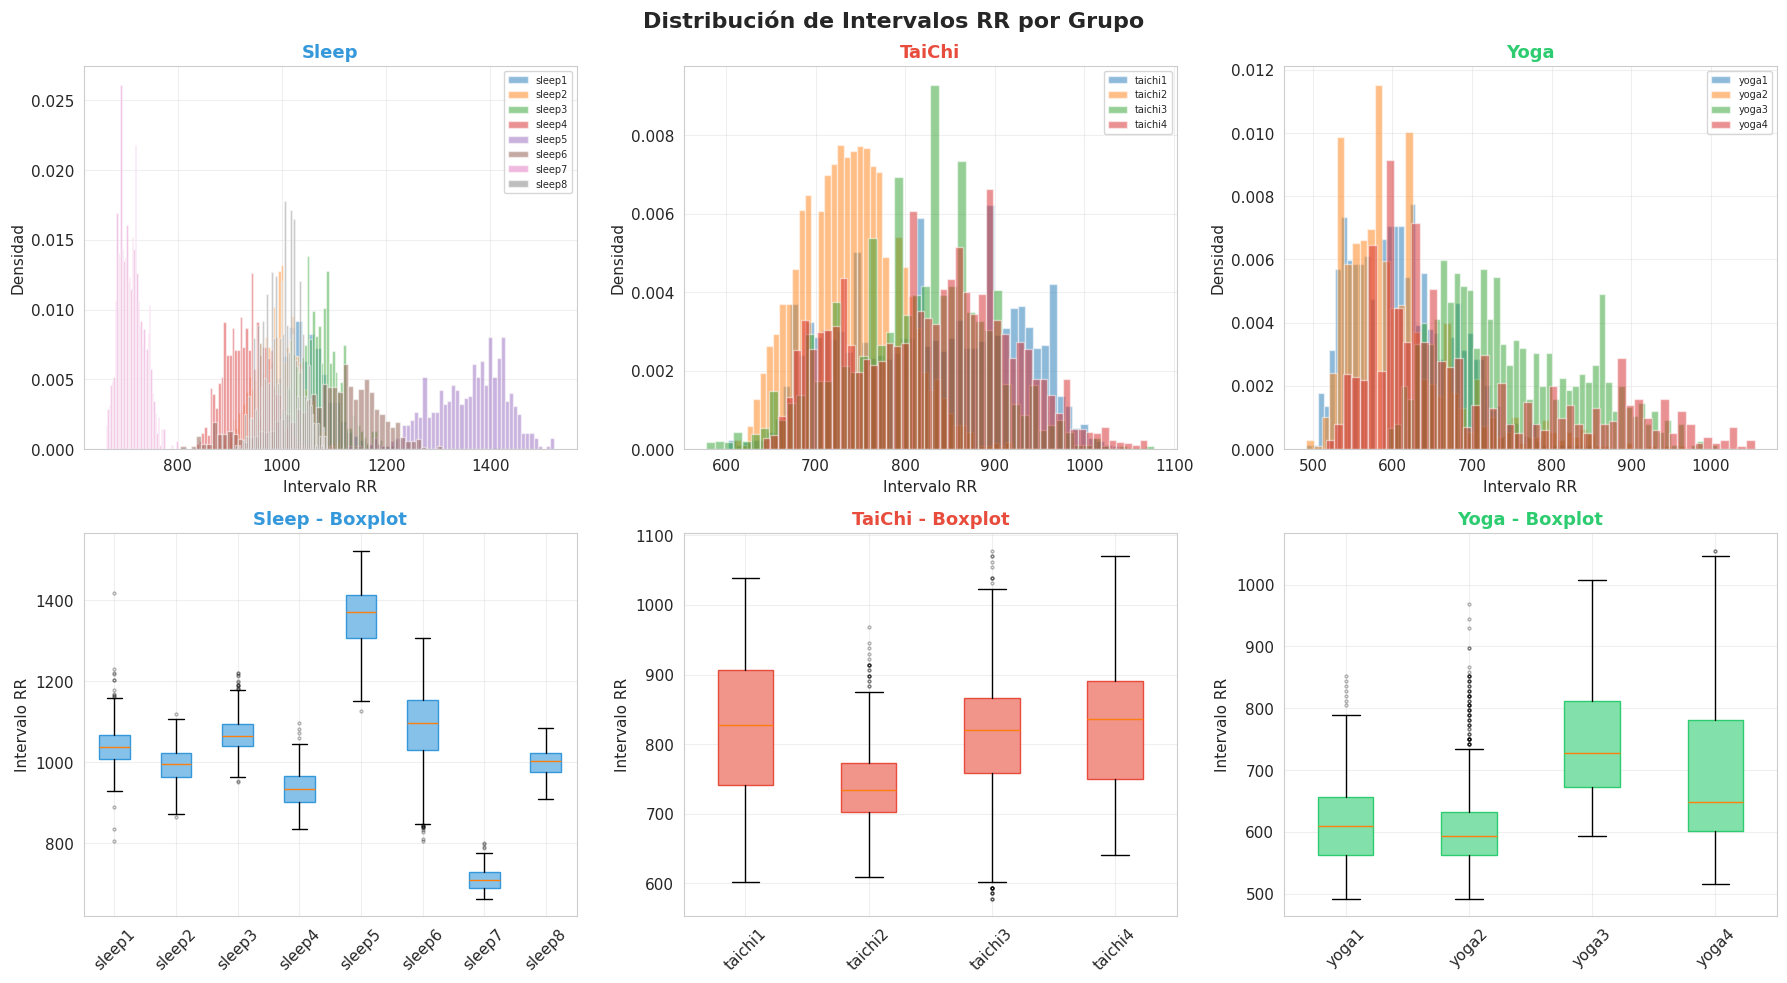

✅ Figura guardada: 02_distribuciones.png


In [ ]:
# =============================================================================
# CELDA 7: DISTRIBUCIONES - HISTOGRAMAS Y BOXPLOTS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Intervalos RR por Grupo',
             fontsize=16, fontweight='bold')

for idx, (group_name, group_info) in enumerate(GROUPS.items()):
    # Histogramas
    ax_h = axes[0, idx]
    if group_name in ecg_data:
        for fname, sig in ecg_data[group_name].items():
            ax_h.hist(sig, bins=50, alpha=0.5, density=True,
                      label=fname.replace('.txt',''))
    ax_h.set_title(f'{group_name}', fontsize=13, fontweight='bold',
                   color=group_info['color'])
    ax_h.set_xlabel('Intervalo RR')
    ax_h.set_ylabel('Densidad')
    ax_h.legend(fontsize=7)
    ax_h.grid(True, alpha=0.3)

    # Boxplots
    ax_b = axes[1, idx]
    if group_name in ecg_data:
        box_data = list(ecg_data[group_name].values())
        box_labels = [f.replace('.txt','') for f in ecg_data[group_name].keys()]
        bp = ax_b.boxplot(box_data, labels=box_labels, patch_artist=True,
                          flierprops={'markersize':2, 'alpha':0.3})
        for patch in bp['boxes']:
            patch.set_facecolor(group_info['color_light'])
            patch.set_edgecolor(group_info['color'])
    ax_b.set_title(f'{group_name} - Boxplot', fontsize=13,
                   fontweight='bold', color=group_info['color'])
    ax_b.tick_params(axis='x', rotation=45)
    ax_b.set_ylabel('Intervalo RR')
    ax_b.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '02_distribuciones.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 02_distribuciones.png")

In [ ]:
# =============================================================================
# CELDA 8: CÁLCULO DE SAMPLE ENTROPY (SampEn)
# =============================================================================

sampen_results = []

print("=" * 65)
print("  CÁLCULO DE SAMPLE ENTROPY")
print(f"  Parámetros: m={SAMPEN_M}, r={SAMPEN_R}·std(señal)")
print("=" * 65)

for group_name in GROUPS:
    if group_name not in ecg_data:
        continue
    print(f"\n📊 {group_name}:")

    for filename, signal in ecg_data[group_name].items():
        try:
            r_value = SAMPEN_R * np.std(signal)

            # SampEn con EntropyHub
            # Retorna: (SampEn_array, A, B)
            result = EH.SampEn(signal, m=SAMPEN_M, r=r_value)
            sampen_vals = result[0]  # Array de SampEn para m=0,1,...,M
            sampen_m = sampen_vals[-1]  # Valor para m=SAMPEN_M

            # También con señal normalizada (z-score)
            sig_norm = (signal - np.mean(signal)) / np.std(signal)
            result_norm = EH.SampEn(sig_norm, m=SAMPEN_M, r=SAMPEN_R)
            sampen_norm = result_norm[0][-1]

            sampen_results.append({
                'Grupo': group_name,
                'Archivo': filename.replace('.txt',''),
                'N_latidos': len(signal),
                'Std_señal': np.std(signal),
                'r_absoluto': r_value,
                'SampEn': sampen_m,
                'SampEn_norm': sampen_norm
            })

            print(f"   ✅ {filename}: SampEn={sampen_m:.6f} | SampEn_norm={sampen_norm:.6f}")

        except Exception as e:
            print(f"   ❌ {filename}: {e}")
            sampen_results.append({
                'Grupo': group_name,
                'Archivo': filename.replace('.txt',''),
                'N_latidos': len(signal),
                'Std_señal': np.std(signal),
                'r_absoluto': SAMPEN_R * np.std(signal),
                'SampEn': np.nan,
                'SampEn_norm': np.nan
            })

df_sampen = pd.DataFrame(sampen_results)

print("\n📋 RESULTADOS SAMPLE ENTROPY:")
display(df_sampen)

df_sampen.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'sample_entropy.csv'), index=False)
print("✅ Tabla guardada: sample_entropy.csv")

  CÁLCULO DE SAMPLE ENTROPY
  Parámetros: m=2, r=0.2·std(señal)

📊 Sleep:
   ✅ sleep1.txt: SampEn=1.725810 | SampEn_norm=1.725810
   ✅ sleep2.txt: SampEn=1.844830 | SampEn_norm=1.844830
   ✅ sleep3.txt: SampEn=1.905520 | SampEn_norm=1.905520
   ✅ sleep4.txt: SampEn=1.770594 | SampEn_norm=1.770594
   ✅ sleep5.txt: SampEn=1.601031 | SampEn_norm=1.601031
   ✅ sleep6.txt: SampEn=1.660917 | SampEn_norm=1.660917
   ✅ sleep7.txt: SampEn=1.585020 | SampEn_norm=1.585020
   ✅ sleep8.txt: SampEn=1.681311 | SampEn_norm=1.681311

📊 TaiChi:
   ✅ taichi1.txt: SampEn=1.054502 | SampEn_norm=1.054502
   ✅ taichi2.txt: SampEn=1.060335 | SampEn_norm=1.060335
   ✅ taichi3.txt: SampEn=1.456171 | SampEn_norm=1.456171
   ✅ taichi4.txt: SampEn=0.988870 | SampEn_norm=0.988870

📊 Yoga:
   ✅ yoga1.txt: SampEn=0.795393 | SampEn_norm=0.795393
   ✅ yoga2.txt: SampEn=0.798055 | SampEn_norm=0.798055
   ✅ yoga3.txt: SampEn=0.766263 | SampEn_norm=0.766263
   ✅ yoga4.txt: SampEn=0.671708 | SampEn_norm=0.671708

📋 RESULTA

,Grupo,Archivo,N_latidos,Std_señal,r_absoluto,SampEn,SampEn_norm
0,Sleep,sleep1,864,50.453050,10.090610,1.725810,1.725810
1,Sleep,sleep2,906,42.149555,8.429911,1.844830,1.844830
2,Sleep,sleep3,841,42.956870,8.591374,1.905520,1.905520
3,Sleep,sleep4,963,41.760751,8.352150,1.770594,1.770594
4,Sleep,sleep5,661,69.491811,13.898362,1.601031,1.601031
5,Sleep,sleep6,830,95.696140,19.139228,1.660917,1.660917
6,Sleep,sleep7,1266,23.818049,4.763610,1.585020,1.585020
7,Sleep,sleep8,899,33.593181,6.718636,1.681311,1.681311
8,TaiChi,taichi1,4034,94.745579,18.949116,1.054502,1.054502
9,TaiChi,taichi2,3599,53.235814,10.647163,1.060335,1.060335


✅ Tabla guardada: sample_entropy.csv


In [ ]:
# =============================================================================
# CELDA 9: CÁLCULO DE PERMUTATION ENTROPY (PermEn) - CORREGIDA
# =============================================================================
import math  # <-- Importar math de Python estándar

permen_results = []

print("=" * 65)
print("  CÁLCULO DE PERMUTATION ENTROPY")
print(f"  Parámetros: m={PERMEN_M}, τ={PERMEN_TAU}")
print(f"  Máximo teórico: ln({PERMEN_M}!) = {np.log2(math.factorial(PERMEN_M)):.4f} bits")
print("=" * 65)

for group_name in GROUPS:
    if group_name not in ecg_data:
        continue
    print(f"\n📊 {group_name}:")

    for filename, signal in ecg_data[group_name].items():
        try:
            # PermEn con EntropyHub
            # Retorna: (PermEn_array, Pnorm_array, cPE)
            result = EH.PermEn(signal, m=PERMEN_M, tau=PERMEN_TAU)
            permen_vals = result[0]
            permen_norm_vals = result[1]

            permen_m = permen_vals[-1]
            permen_norm_m = permen_norm_vals[-1]

            permen_results.append({
                'Grupo': group_name,
                'Archivo': filename.replace('.txt',''),
                'N_latidos': len(signal),
                'PermEn': permen_m,
                'PermEn_norm': permen_norm_m
            })

            print(f"   ✅ {filename}: PermEn={permen_m:.6f} | PermEn_norm={permen_norm_m:.6f}")

        except Exception as e:
            print(f"   ❌ {filename}: {e}")
            permen_results.append({
                'Grupo': group_name,
                'Archivo': filename.replace('.txt',''),
                'N_latidos': len(signal),
                'PermEn': np.nan,
                'PermEn_norm': np.nan
            })

df_permen = pd.DataFrame(permen_results)

print("\n📋 RESULTADOS PERMUTATION ENTROPY:")
display(df_permen)

df_permen.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'permutation_entropy.csv'), index=False)
print("✅ Tabla guardada: permutation_entropy.csv")

  CÁLCULO DE PERMUTATION ENTROPY
  Parámetros: m=3, τ=1
  Máximo teórico: ln(3!) = 2.5850 bits

📊 Sleep:
   ✅ sleep1.txt: PermEn=2.466943 | PermEn_norm=1.233472
   ✅ sleep2.txt: PermEn=2.458382 | PermEn_norm=1.229191
   ✅ sleep3.txt: PermEn=2.513666 | PermEn_norm=1.256833
   ✅ sleep4.txt: PermEn=2.453526 | PermEn_norm=1.226763
   ✅ sleep5.txt: PermEn=2.482056 | PermEn_norm=1.241028
   ✅ sleep6.txt: PermEn=2.539095 | PermEn_norm=1.269548
   ✅ sleep7.txt: PermEn=2.209730 | PermEn_norm=1.104865
   ✅ sleep8.txt: PermEn=2.447837 | PermEn_norm=1.223919

📊 TaiChi:
   ✅ taichi1.txt: PermEn=2.221502 | PermEn_norm=1.110751
   ✅ taichi2.txt: PermEn=2.295543 | PermEn_norm=1.147771
   ✅ taichi3.txt: PermEn=2.478822 | PermEn_norm=1.239411
   ✅ taichi4.txt: PermEn=2.214656 | PermEn_norm=1.107328

📊 Yoga:
   ✅ yoga1.txt: PermEn=2.246412 | PermEn_norm=1.123206
   ✅ yoga2.txt: PermEn=2.135821 | PermEn_norm=1.067910
   ✅ yoga3.txt: PermEn=2.022244 | PermEn_norm=1.011122
   ✅ yoga4.txt: PermEn=2.130754 | 

,Grupo,Archivo,N_latidos,PermEn,PermEn_norm
0,Sleep,sleep1,864,2.466943,1.233472
1,Sleep,sleep2,906,2.458382,1.229191
2,Sleep,sleep3,841,2.513666,1.256833
3,Sleep,sleep4,963,2.453526,1.226763
4,Sleep,sleep5,661,2.482056,1.241028
5,Sleep,sleep6,830,2.539095,1.269548
6,Sleep,sleep7,1266,2.209730,1.104865
7,Sleep,sleep8,899,2.447837,1.223919
8,TaiChi,taichi1,4034,2.221502,1.110751
9,TaiChi,taichi2,3599,2.295543,1.147771


✅ Tabla guardada: permutation_entropy.csv


In [ ]:
# =============================================================================
# CELDA 10: TABLA COMBINADA Y RESUMEN
# =============================================================================

# Combinar ambas entropías
df_combined = pd.merge(
    df_sampen[['Grupo', 'Archivo', 'N_latidos', 'SampEn', 'SampEn_norm']],
    df_permen[['Archivo', 'PermEn', 'PermEn_norm']],
    on='Archivo',
    how='outer'
)

print("=" * 65)
print("  TABLA COMBINADA DE ENTROPÍAS")
print("=" * 65)
display(df_combined)

# Resumen por grupo
print("\n📊 RESUMEN POR GRUPO (Media ± Std):")
print("-" * 65)

summary_rows = []
for group in GROUP_ORDER:
    gd = df_combined[df_combined['Grupo'] == group]
    row = {
        'Grupo': group,
        'N': len(gd),
        'SampEn': f"{gd['SampEn'].mean():.6f} ± {gd['SampEn'].std():.6f}",
        'SampEn_norm': f"{gd['SampEn_norm'].mean():.6f} ± {gd['SampEn_norm'].std():.6f}",
        'PermEn': f"{gd['PermEn'].mean():.6f} ± {gd['PermEn'].std():.6f}",
        'PermEn_norm': f"{gd['PermEn_norm'].mean():.6f} ± {gd['PermEn_norm'].std():.6f}"
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# Guardar
df_combined.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'entropia_combinada.csv'), index=False)
df_summary.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'entropia_resumen_grupo.csv'), index=False)
print("✅ Tablas guardadas: entropia_combinada.csv, entropia_resumen_grupo.csv")

  TABLA COMBINADA DE ENTROPÍAS


,Grupo,Archivo,N_latidos,SampEn,SampEn_norm,PermEn,PermEn_norm
0,Sleep,sleep1,864,1.725810,1.725810,2.466943,1.233472
1,Sleep,sleep2,906,1.844830,1.844830,2.458382,1.229191
2,Sleep,sleep3,841,1.905520,1.905520,2.513666,1.256833
3,Sleep,sleep4,963,1.770594,1.770594,2.453526,1.226763
4,Sleep,sleep5,661,1.601031,1.601031,2.482056,1.241028
5,Sleep,sleep6,830,1.660917,1.660917,2.539095,1.269548
6,Sleep,sleep7,1266,1.585020,1.585020,2.209730,1.104865
7,Sleep,sleep8,899,1.681311,1.681311,2.447837,1.223919
8,TaiChi,taichi1,4034,1.054502,1.054502,2.221502,1.110751
9,TaiChi,taichi2,3599,1.060335,1.060335,2.295543,1.147771



📊 RESUMEN POR GRUPO (Media ± Std):
-----------------------------------------------------------------


,Grupo,N,SampEn,SampEn_norm,PermEn,PermEn_norm
0,Sleep,8,1.721879 ± 0.113343,1.721879 ± 0.113343,2.446405 ± 0.100726,1.223202 ± 0.050363
1,TaiChi,4,1.139970 ± 0.213277,1.139970 ± 0.213277,2.302631 ± 0.123038,1.151315 ± 0.061519
2,Yoga,4,0.757855 ± 0.059209,0.757855 ± 0.059209,2.133808 ± 0.091541,1.066904 ± 0.045771


✅ Tablas guardadas: entropia_combinada.csv, entropia_resumen_grupo.csv


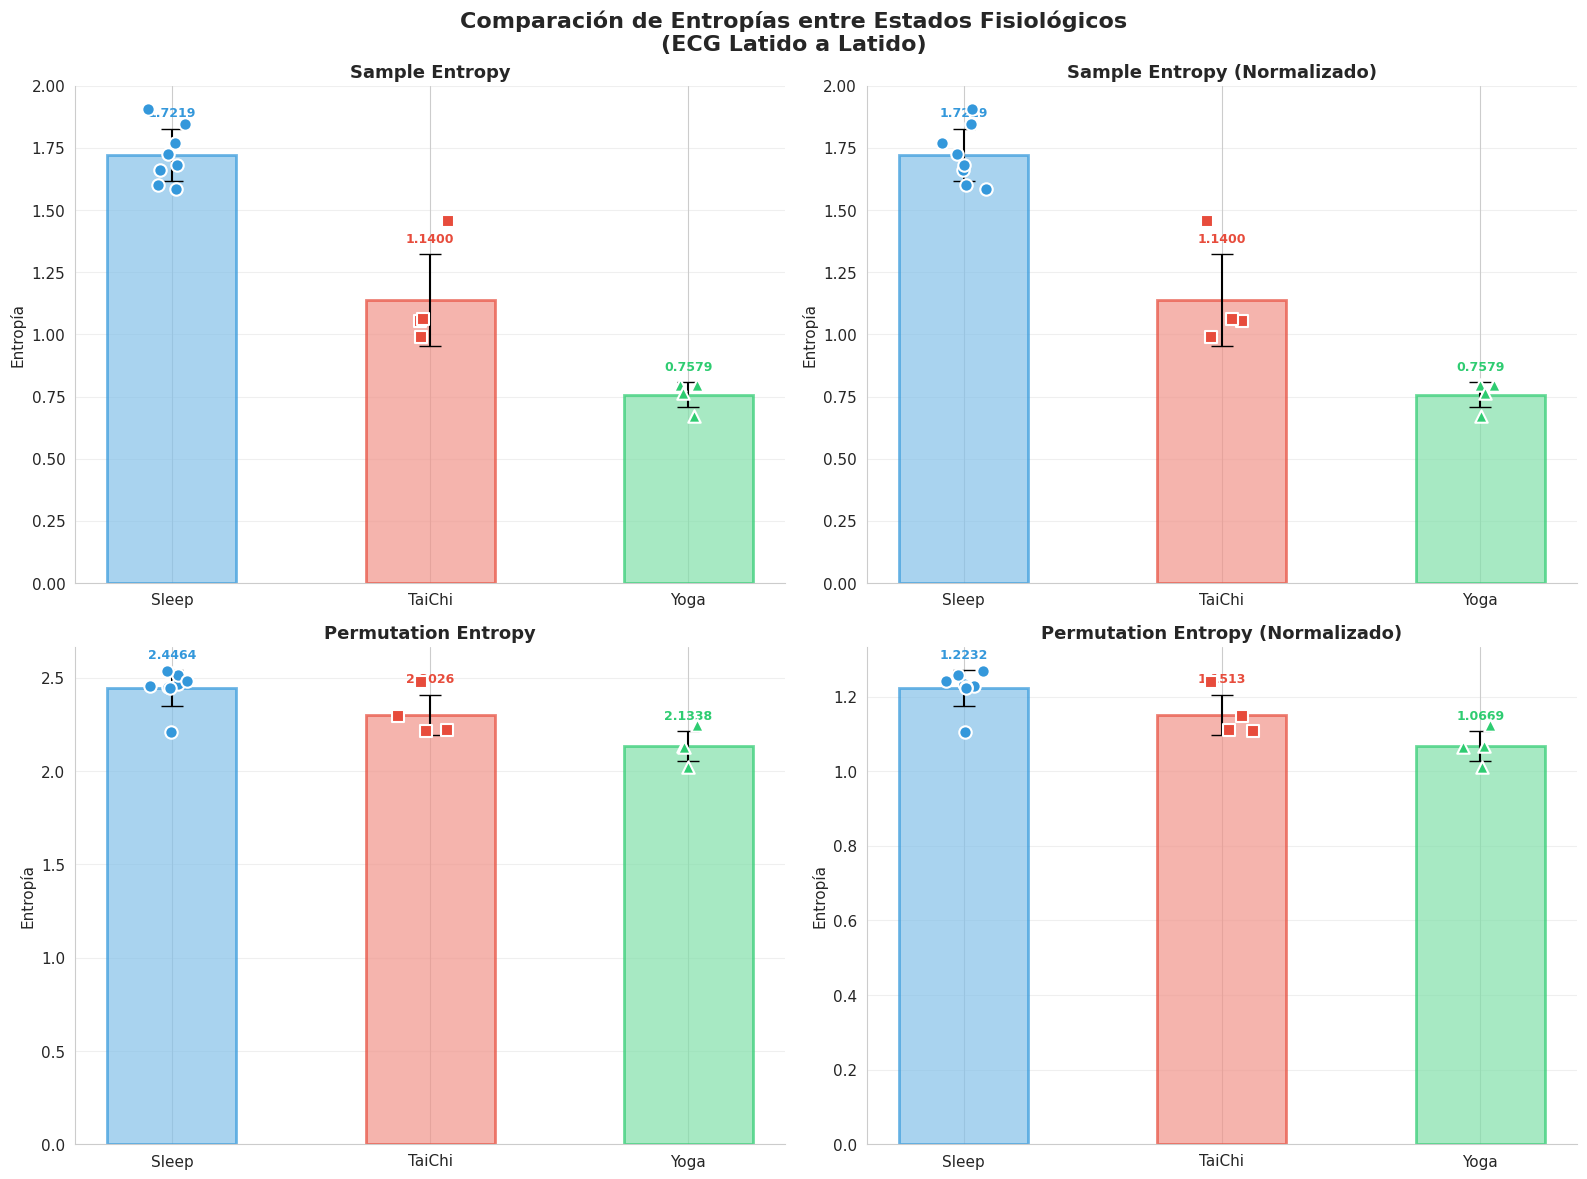

✅ Figura guardada: 03_comparacion_entropias.png


In [ ]:
# =============================================================================
# CELDA 11: GRÁFICA DE BARRAS + PUNTOS INDIVIDUALES
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación de Entropías entre Estados Fisiológicos\n(ECG Latido a Latido)',
             fontsize=16, fontweight='bold')

measures = [
    ('SampEn', 'Sample Entropy'),
    ('SampEn_norm', 'Sample Entropy (Normalizado)'),
    ('PermEn', 'Permutation Entropy'),
    ('PermEn_norm', 'Permutation Entropy (Normalizado)')
]

colors = [GROUPS[g]['color'] for g in GROUP_ORDER]
colors_l = [GROUPS[g]['color_light'] for g in GROUP_ORDER]

for plot_idx, (col, title) in enumerate(measures):
    ax = axes[plot_idx // 2, plot_idx % 2]

    means, stds = [], []
    for g in GROUP_ORDER:
        vals = df_combined[df_combined['Grupo'] == g][col].dropna().values
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    x = np.arange(len(GROUP_ORDER))

    # Barras
    ax.bar(x, means, yerr=stds, color=colors_l, edgecolor=colors,
           linewidth=2, capsize=8, alpha=0.7, width=0.5)

    # Puntos individuales
    for i, g in enumerate(GROUP_ORDER):
        vals = df_combined[df_combined['Grupo'] == g][col].dropna().values
        jitter = np.random.normal(0, 0.05, size=len(vals))
        ax.scatter(x[i] + jitter, vals, color=colors[i], s=80, zorder=5,
                   edgecolors='white', linewidth=1.5, marker=GROUPS[g]['marker'])

    # Anotar medias
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(x[i], m + s + 0.02 * max(means), f'{m:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=colors[i])

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, fontsize=11)
    ax.set_ylabel('Entropía', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '03_comparacion_entropias.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 03_comparacion_entropias.png")

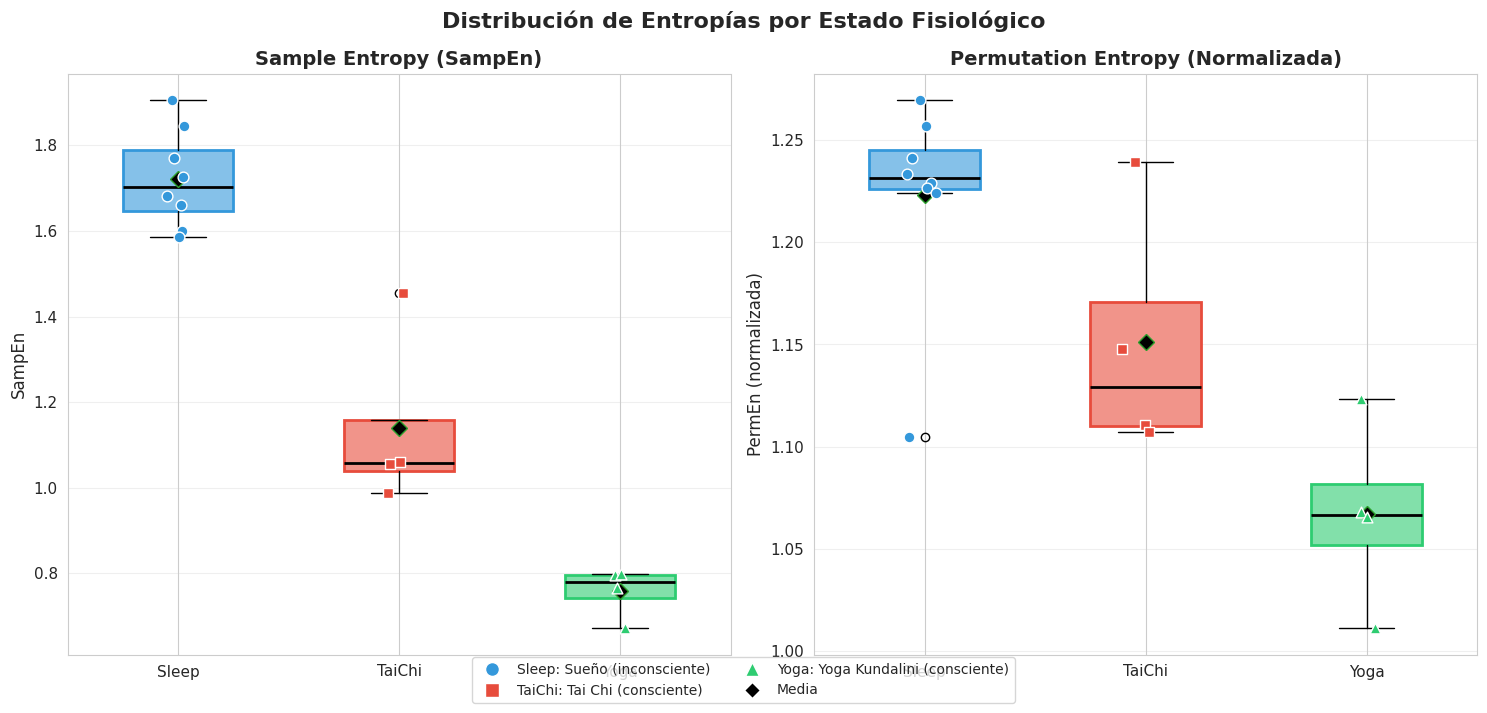

✅ Figura guardada: 04_boxplots.png


In [ ]:
# =============================================================================
# CELDA 12: BOXPLOTS DETALLADOS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Distribución de Entropías por Estado Fisiológico',
             fontsize=16, fontweight='bold')

colors = [GROUPS[g]['color'] for g in GROUP_ORDER]
colors_l = [GROUPS[g]['color_light'] for g in GROUP_ORDER]

# --- Sample Entropy ---
ax1 = axes[0]
data_se = [df_combined[df_combined['Grupo']==g]['SampEn'].dropna().values for g in GROUP_ORDER]

bp1 = ax1.boxplot(data_se, labels=GROUP_ORDER, patch_artist=True,
                  widths=0.5, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='black', markersize=8),
                  medianprops=dict(color='black', linewidth=2))

for i, (patch, c, cl) in enumerate(zip(bp1['boxes'], colors, colors_l)):
    patch.set_facecolor(cl)
    patch.set_edgecolor(c)
    patch.set_linewidth(2)
    vals = data_se[i]
    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax1.scatter(np.full(len(vals), i+1) + jitter, vals, color=c,
                s=60, zorder=5, edgecolors='white', linewidth=1,
                marker=GROUPS[GROUP_ORDER[i]]['marker'])

ax1.set_title('Sample Entropy (SampEn)', fontsize=14, fontweight='bold')
ax1.set_ylabel('SampEn', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# --- Permutation Entropy ---
ax2 = axes[1]
data_pe = [df_combined[df_combined['Grupo']==g]['PermEn_norm'].dropna().values for g in GROUP_ORDER]

bp2 = ax2.boxplot(data_pe, labels=GROUP_ORDER, patch_artist=True,
                  widths=0.5, showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='black', markersize=8),
                  medianprops=dict(color='black', linewidth=2))

for i, (patch, c, cl) in enumerate(zip(bp2['boxes'], colors, colors_l)):
    patch.set_facecolor(cl)
    patch.set_edgecolor(c)
    patch.set_linewidth(2)
    vals = data_pe[i]
    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax2.scatter(np.full(len(vals), i+1) + jitter, vals, color=c,
                s=60, zorder=5, edgecolors='white', linewidth=1,
                marker=GROUPS[GROUP_ORDER[i]]['marker'])

ax2.set_title('Permutation Entropy (Normalizada)', fontsize=14, fontweight='bold')
ax2.set_ylabel('PermEn (normalizada)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Leyenda
legend_el = [plt.Line2D([0],[0], marker=GROUPS[g]['marker'], color='w',
              markerfacecolor=GROUPS[g]['color'], markersize=10,
              label=f'{g}: {GROUPS[g]["description"]}') for g in GROUP_ORDER]
legend_el.append(plt.Line2D([0],[0], marker='D', color='w',
                  markerfacecolor='black', markersize=8, label='Media'))
fig.legend(handles=legend_el, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '04_boxplots.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 04_boxplots.png")

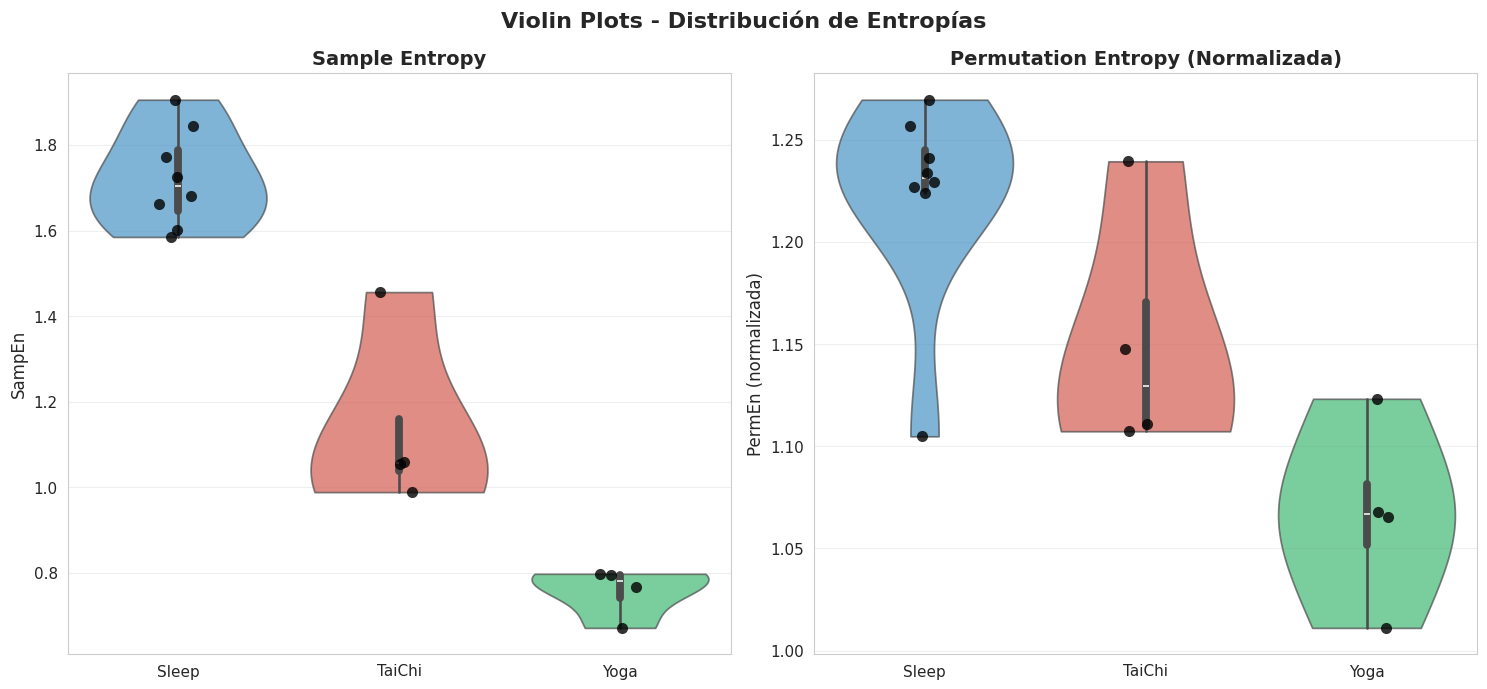

✅ Figura guardada: 05_violin_plots.png


In [ ]:
# =============================================================================
# CELDA 13: VIOLIN PLOTS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Violin Plots - Distribución de Entropías',
             fontsize=16, fontweight='bold')

palette = {g: GROUPS[g]['color'] for g in GROUP_ORDER}

# Sample Entropy
sns.violinplot(data=df_combined, x='Grupo', y='SampEn',
               order=GROUP_ORDER, palette=palette, ax=axes[0],
               inner='box', alpha=0.7, cut=0)
sns.stripplot(data=df_combined, x='Grupo', y='SampEn',
              order=GROUP_ORDER, color='black', size=8, ax=axes[0],
              jitter=True, alpha=0.8)
axes[0].set_title('Sample Entropy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('SampEn', fontsize=12)
axes[0].set_xlabel('')
axes[0].grid(True, alpha=0.3, axis='y')

# Permutation Entropy
sns.violinplot(data=df_combined, x='Grupo', y='PermEn_norm',
               order=GROUP_ORDER, palette=palette, ax=axes[1],
               inner='box', alpha=0.7, cut=0)
sns.stripplot(data=df_combined, x='Grupo', y='PermEn_norm',
              order=GROUP_ORDER, color='black', size=8, ax=axes[1],
              jitter=True, alpha=0.8)
axes[1].set_title('Permutation Entropy (Normalizada)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PermEn (normalizada)', fontsize=12)
axes[1].set_xlabel('')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '05_violin_plots.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 05_violin_plots.png")

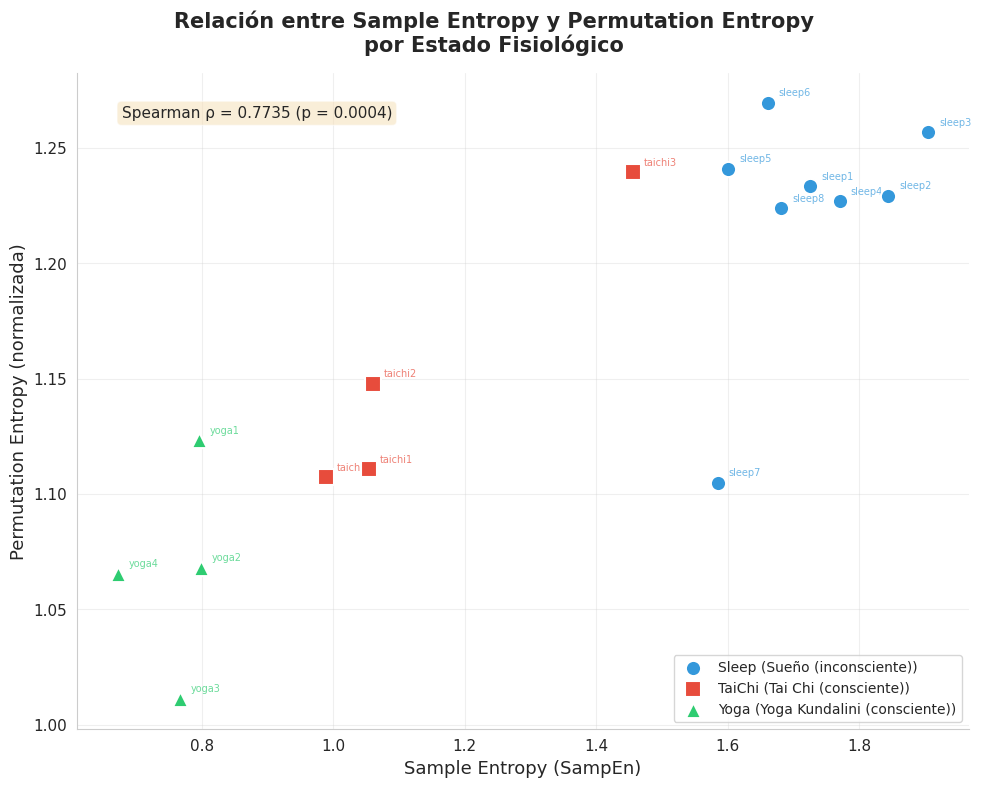

✅ Figura guardada: 06_scatter_sampen_vs_permen.png


In [ ]:
# =============================================================================
# CELDA 14: SCATTER PLOT - SampEn vs PermEn
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Relación entre Sample Entropy y Permutation Entropy\npor Estado Fisiológico',
             fontsize=15, fontweight='bold')

for group in GROUP_ORDER:
    data = df_combined[df_combined['Grupo'] == group]
    ax.scatter(data['SampEn'], data['PermEn_norm'],
               color=GROUPS[group]['color'], s=120,
               marker=GROUPS[group]['marker'],
               label=f'{group} ({GROUPS[group]["description"]})',
               edgecolors='white', linewidth=1.5, zorder=5)

    # Anotar puntos
    for _, row in data.iterrows():
        ax.annotate(row['Archivo'],
                    (row['SampEn'], row['PermEn_norm']),
                    textcoords="offset points", xytext=(8, 5),
                    fontsize=7, alpha=0.7, color=GROUPS[group]['color'])

ax.set_xlabel('Sample Entropy (SampEn)', fontsize=13)
ax.set_ylabel('Permutation Entropy (normalizada)', fontsize=13)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Correlación global
valid = df_combined.dropna(subset=['SampEn', 'PermEn_norm'])
r_corr, p_corr = stats.spearmanr(valid['SampEn'], valid['PermEn_norm'])
ax.text(0.05, 0.95, f'Spearman ρ = {r_corr:.4f} (p = {p_corr:.4f})',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '06_scatter_sampen_vs_permen.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 06_scatter_sampen_vs_permen.png")

In [ ]:
# =============================================================================
# CELDA 15: VERIFICACIÓN DE SUPUESTOS ESTADÍSTICOS
# =============================================================================

print("=" * 65)
print("  VERIFICACIÓN DE SUPUESTOS ESTADÍSTICOS")
print("=" * 65)

entropy_cols = {
    'SampEn': 'Sample Entropy',
    'PermEn_norm': 'Permutation Entropy (norm)'
}

assumption_results = []

for col, name in entropy_cols.items():
    print(f"\n{'─' * 50}")
    print(f"📊 {name}")
    print(f"{'─' * 50}")

    # Shapiro-Wilk por grupo
    print("\n   🔍 Shapiro-Wilk (Normalidad):")
    group_data = []
    for g in GROUP_ORDER:
        vals = df_combined[df_combined['Grupo']==g][col].dropna().values
        group_data.append(vals)

        if len(vals) >= 3:
            w, p = shapiro(vals)
            result = "Normal" if p > ALPHA else "No normal"
            symbol = "✅" if p > ALPHA else "❌"
            print(f"     {g} (n={len(vals)}): W={w:.4f}, p={p:.4f} → {symbol} {result}")
            assumption_results.append({
                'Medida': name, 'Test': 'Shapiro-Wilk',
                'Grupo': g, 'Estadístico': w, 'p_valor': p, 'Resultado': result
            })
        else:
            print(f"     {g} (n={len(vals)}): Muestra insuficiente")

    # Levene
    print("\n   🔍 Levene (Homogeneidad de varianzas):")
    if all(len(d) >= 2 for d in group_data):
        w_l, p_l = levene(*group_data)
        result_l = "Homogéneas" if p_l > ALPHA else "No homogéneas"
        symbol_l = "✅" if p_l > ALPHA else "❌"
        print(f"     W={w_l:.4f}, p={p_l:.4f} → {symbol_l} {result_l}")
        assumption_results.append({
            'Medida': name, 'Test': 'Levene',
            'Grupo': 'Todos', 'Estadístico': w_l, 'p_valor': p_l, 'Resultado': result_l
        })

df_assumptions = pd.DataFrame(assumption_results)
display(df_assumptions)

print("\n" + "─" * 50)
print("📌 NOTA: Con muestras pequeñas (n=4, 4, 8), Shapiro-Wilk")
print("   tiene bajo poder. Se justifica usar Kruskal-Wallis")
print("   (no paramétrico) + Dunn Post Hoc.")
print("─" * 50)

  VERIFICACIÓN DE SUPUESTOS ESTADÍSTICOS

──────────────────────────────────────────────────
📊 Sample Entropy
──────────────────────────────────────────────────

   🔍 Shapiro-Wilk (Normalidad):
     Sleep (n=8): W=0.9531, p=0.7421 → ✅ Normal
     TaiChi (n=4): W=0.7604, p=0.0481 → ❌ No normal
     Yoga (n=4): W=0.7992, p=0.1008 → ✅ Normal

   🔍 Levene (Homogeneidad de varianzas):
     W=0.5987, p=0.5640 → ✅ Homogéneas

──────────────────────────────────────────────────
📊 Permutation Entropy (norm)
──────────────────────────────────────────────────

   🔍 Shapiro-Wilk (Normalidad):
     Sleep (n=8): W=0.7166, p=0.0035 → ❌ No normal
     TaiChi (n=4): W=0.8276, p=0.1616 → ✅ Normal
     Yoga (n=4): W=0.9545, p=0.7443 → ✅ Normal

   🔍 Levene (Homogeneidad de varianzas):
     W=0.1976, p=0.8231 → ✅ Homogéneas


,Medida,Test,Grupo,Estadístico,p_valor,Resultado
0,Sample Entropy,Shapiro-Wilk,Sleep,0.953065,0.742057,Normal
1,Sample Entropy,Shapiro-Wilk,TaiChi,0.760419,0.048114,No normal
2,Sample Entropy,Shapiro-Wilk,Yoga,0.799177,0.100752,Normal
3,Sample Entropy,Levene,Todos,0.598674,0.564007,Homogéneas
4,Permutation Entropy (norm),Shapiro-Wilk,Sleep,0.716558,0.003462,No normal
5,Permutation Entropy (norm),Shapiro-Wilk,TaiChi,0.827580,0.161579,Normal
6,Permutation Entropy (norm),Shapiro-Wilk,Yoga,0.954498,0.744302,Normal
7,Permutation Entropy (norm),Levene,Todos,0.197609,0.823110,Homogéneas



──────────────────────────────────────────────────
📌 NOTA: Con muestras pequeñas (n=4, 4, 8), Shapiro-Wilk
   tiene bajo poder. Se justifica usar Kruskal-Wallis
   (no paramétrico) + Dunn Post Hoc.
──────────────────────────────────────────────────


In [ ]:
# =============================================================================
# CELDA 16: TEST DE KRUSKAL-WALLIS
# =============================================================================

print("=" * 65)
print("  TEST DE KRUSKAL-WALLIS")
print("  (Alternativa no paramétrica al ANOVA de una vía)")
print("  H0: Las distribuciones de los 3 grupos son iguales")
print("  H1: Al menos un grupo difiere")
print("=" * 65)

entropy_cols = {
    'SampEn': 'Sample Entropy',
    'SampEn_norm': 'Sample Entropy (Norm)',
    'PermEn': 'Permutation Entropy',
    'PermEn_norm': 'Permutation Entropy (Norm)'
}

kw_results = []

for col, name in entropy_cols.items():
    data_groups = []
    for g in GROUP_ORDER:
        vals = df_combined[df_combined['Grupo']==g][col].dropna().values
        data_groups.append(vals)

    h_stat, p_val = kruskal(*data_groups)

    # Tamaño del efecto: eta² = (H - k + 1) / (N - k)
    n_total = sum(len(d) for d in data_groups)
    k = len(data_groups)
    eta_sq = (h_stat - k + 1) / (n_total - k) if n_total > k else np.nan

    # Interpretación
    if eta_sq < 0.01: eff = "Negligible"
    elif eta_sq < 0.06: eff = "Pequeño"
    elif eta_sq < 0.14: eff = "Mediano"
    else: eff = "Grande"

    sig = "✅ SIGNIFICATIVO" if p_val < ALPHA else "❌ No significativo"

    print(f"\n{'─' * 55}")
    print(f"📊 {name}")
    print(f"   H({k-1}) = {h_stat:.4f}")
    print(f"   p-valor = {p_val:.6f}")
    print(f"   η² = {eta_sq:.4f} ({eff})")
    print(f"   → {sig} (α={ALPHA})")
    for i, g in enumerate(GROUP_ORDER):
        v = data_groups[i]
        print(f"   {g}: Mediana={np.median(v):.6f}, Media={np.mean(v):.6f}, n={len(v)}")

    kw_results.append({
        'Medida': name, 'H': h_stat, 'p_valor': p_val,
        'eta_cuadrado': eta_sq, 'Tamaño_efecto': eff,
        'Significativo': p_val < ALPHA
    })

df_kw = pd.DataFrame(kw_results)

print(f"\n{'─' * 55}")
print("\n📋 RESUMEN KRUSKAL-WALLIS:")
display(df_kw)

df_kw.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'kruskal_wallis.csv'), index=False)
print("✅ Tabla guardada: kruskal_wallis.csv")

  TEST DE KRUSKAL-WALLIS
  (Alternativa no paramétrica al ANOVA de una vía)
  H0: Las distribuciones de los 3 grupos son iguales
  H1: Al menos un grupo difiere

───────────────────────────────────────────────────────
📊 Sample Entropy
   H(2) = 12.7059
   p-valor = 0.001742
   η² = 0.8235 (Grande)
   → ✅ SIGNIFICATIVO (α=0.05)
   Sleep: Mediana=1.703560, Media=1.721879, n=8
   TaiChi: Mediana=1.057419, Media=1.139970, n=4
   Yoga: Mediana=0.780828, Media=0.757855, n=4

───────────────────────────────────────────────────────
📊 Sample Entropy (Norm)
   H(2) = 12.7059
   p-valor = 0.001742
   η² = 0.8235 (Grande)
   → ✅ SIGNIFICATIVO (α=0.05)
   Sleep: Mediana=1.703560, Media=1.721879, n=8
   TaiChi: Mediana=1.057419, Media=1.139970, n=4
   Yoga: Mediana=0.780828, Media=0.757855, n=4

───────────────────────────────────────────────────────
📊 Permutation Entropy
   H(2) = 7.8254
   p-valor = 0.019987
   η² = 0.4481 (Grande)
   → ✅ SIGNIFICATIVO (α=0.05)
   Sleep: Mediana=2.462662, Media=2.

,Medida,H,p_valor,eta_cuadrado,Tamaño_efecto,Significativo
0,Sample Entropy,12.705882,0.001742,0.823529,Grande,True
1,Sample Entropy (Norm),12.705882,0.001742,0.823529,Grande,True
2,Permutation Entropy,7.825368,0.019987,0.448105,Grande,True
3,Permutation Entropy (Norm),7.825368,0.019987,0.448105,Grande,True


✅ Tabla guardada: kruskal_wallis.csv


In [ ]:
# =============================================================================
# CELDA 17: TEST POST HOC DE DUNN
# =============================================================================

print("=" * 65)
print("  TEST POST HOC DE DUNN")
print("  (Comparaciones por pares con corrección de Bonferroni)")
print("=" * 65)

entropy_cols = {
    'SampEn': 'Sample Entropy',
    'SampEn_norm': 'Sample Entropy (Norm)',
    'PermEn': 'Permutation Entropy',
    'PermEn_norm': 'Permutation Entropy (Norm)'
}

dunn_all = []
dunn_matrices = {}

for col, name in entropy_cols.items():
    print(f"\n{'─' * 55}")
    print(f"📊 {name}")

    df_temp = df_combined[['Grupo', col]].dropna()

    # Test de Dunn
    dunn_mat = sp.posthoc_dunn(df_temp, val_col=col, group_col='Grupo',
                                p_adjust='bonferroni')
    dunn_matrices[col] = dunn_mat

    print(f"\n   Matriz de p-valores:")
    display(dunn_mat.round(6))

    # Comparaciones individuales
    print(f"\n   Comparaciones por pares:")
    pairs = list(combinations(GROUP_ORDER, 2))

    for g1, g2 in pairs:
        p = dunn_mat.loc[g1, g2]

        # Rank-biserial como tamaño del efecto
        d1 = df_combined[df_combined['Grupo']==g1][col].dropna().values
        d2 = df_combined[df_combined['Grupo']==g2][col].dropna().values
        u_stat, _ = mannwhitneyu(d1, d2, alternative='two-sided')
        r_rb = 1 - (2 * u_stat) / (len(d1) * len(d2))

        sig = "✅ SIG" if p < ALPHA else "❌ NS"
        print(f"     {g1} vs {g2}: p={p:.6f} {sig} | "
              f"Med: {np.median(d1):.4f} vs {np.median(d2):.4f} | "
              f"r_rb={r_rb:.4f}")

        dunn_all.append({
            'Medida': name,
            'Comparación': f'{g1} vs {g2}',
            'p_valor': p,
            'Significativo': p < ALPHA,
            f'Mediana_{g1}': np.median(d1),
            f'Mediana_{g2}': np.median(d2),
            'Rank_biserial_r': r_rb
        })

df_dunn = pd.DataFrame(dunn_all)

print(f"\n{'─' * 55}")
print("\n📋 RESUMEN DUNN POST HOC:")
display(df_dunn)

df_dunn.to_csv(os.path.join(RESULTS_PATH, 'tablas', 'dunn_posthoc.csv'), index=False)
print("✅ Tabla guardada: dunn_posthoc.csv")

  TEST POST HOC DE DUNN
  (Comparaciones por pares con corrección de Bonferroni)

───────────────────────────────────────────────────────
📊 Sample Entropy

   Matriz de p-valores:


,Sleep,TaiChi,Yoga
Sleep,1.000000,0.118775,0.001811
TaiChi,0.118775,1.000000,0.704291
Yoga,0.001811,0.704291,1.000000



   Comparaciones por pares:
     Sleep vs TaiChi: p=0.118775 ❌ NS | Med: 1.7036 vs 1.0574 | r_rb=-1.0000
     Sleep vs Yoga: p=0.001811 ✅ SIG | Med: 1.7036 vs 0.7808 | r_rb=-1.0000
     TaiChi vs Yoga: p=0.704291 ❌ NS | Med: 1.0574 vs 0.7808 | r_rb=-1.0000

───────────────────────────────────────────────────────
📊 Sample Entropy (Norm)

   Matriz de p-valores:


,Sleep,TaiChi,Yoga
Sleep,1.000000,0.118775,0.001811
TaiChi,0.118775,1.000000,0.704291
Yoga,0.001811,0.704291,1.000000



   Comparaciones por pares:
     Sleep vs TaiChi: p=0.118775 ❌ NS | Med: 1.7036 vs 1.0574 | r_rb=-1.0000
     Sleep vs Yoga: p=0.001811 ✅ SIG | Med: 1.7036 vs 0.7808 | r_rb=-1.0000
     TaiChi vs Yoga: p=0.704291 ❌ NS | Med: 1.0574 vs 0.7808 | r_rb=-1.0000

───────────────────────────────────────────────────────
📊 Permutation Entropy

   Matriz de p-valores:


...


   Comparaciones por pares:
     Sleep vs TaiChi: p=0.741063 ❌ NS | Med: 2.4627 vs 2.2585 | r_rb=-0.5000
     Sleep vs Yoga: p=0.015967 ✅ SIG | Med: 2.4627 vs 2.1333 | r_rb=-0.9375
     TaiChi vs Yoga: p=0.474769 ❌ NS | Med: 2.2585 vs 2.1333 | r_rb=-0.7500

───────────────────────────────────────────────────────
📊 Permutation Entropy (Norm)

   Matriz de p-valores:


,Sleep,TaiChi,Yoga
Sleep,1.000000,0.741063,0.015967
TaiChi,0.741063,1.000000,0.474769
Yoga,0.015967,0.474769,1.000000



   Comparaciones por pares:
     Sleep vs TaiChi: p=0.741063 ❌ NS | Med: 1.2313 vs 1.1293 | r_rb=-0.5000
     Sleep vs Yoga: p=0.015967 ✅ SIG | Med: 1.2313 vs 1.0666 | r_rb=-0.9375
     TaiChi vs Yoga: p=0.474769 ❌ NS | Med: 1.1293 vs 1.0666 | r_rb=-0.7500

───────────────────────────────────────────────────────

📋 RESUMEN DUNN POST HOC:


,Medida,Comparación,p_valor,Significativo,Mediana_Sleep,Mediana_TaiChi,Rank_biserial_r,Mediana_Yoga
0,Sample Entropy,Sleep vs TaiChi,0.118775,False,1.703560,1.057419,-1.0000,NaN
1,Sample Entropy,Sleep vs Yoga,0.001811,True,1.703560,NaN,-1.0000,0.780828
2,Sample Entropy,TaiChi vs Yoga,0.704291,False,NaN,1.057419,-1.0000,0.780828
3,Sample Entropy (Norm),Sleep vs TaiChi,0.118775,False,1.703560,1.057419,-1.0000,NaN
4,Sample Entropy (Norm),Sleep vs Yoga,0.001811,True,1.703560,NaN,-1.0000,0.780828
5,Sample Entropy (Norm),TaiChi vs Yoga,0.704291,False,NaN,1.057419,-1.0000,0.780828
6,Permutation Entropy,Sleep vs TaiChi,0.741063,False,2.462662,2.258522,-0.5000,NaN
7,Permutation Entropy,Sleep vs Yoga,0.015967,True,2.462662,NaN,-0.9375,2.133287
8,Permutation Entropy,TaiChi vs Yoga,0.474769,False,NaN,2.258522,-0.7500,2.133287
9,Permutation Entropy (Norm),Sleep vs TaiChi,0.741063,False,1.231331,1.129261,-0.5000,NaN


✅ Tabla guardada: dunn_posthoc.csv


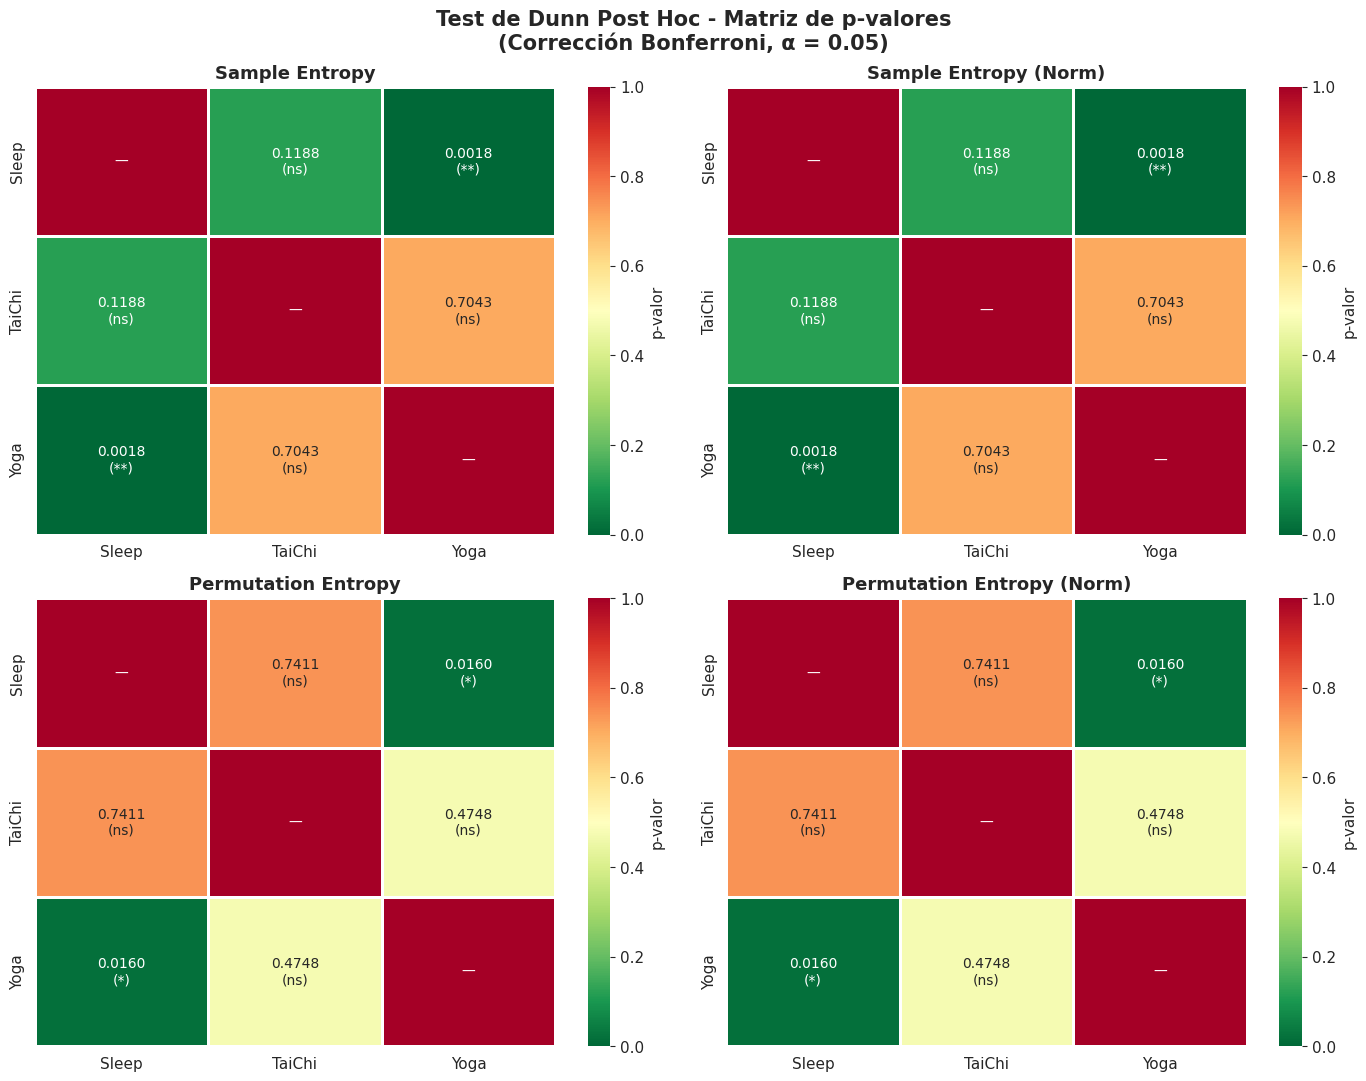

✅ Figura guardada: 07_dunn_heatmaps.png


In [ ]:
# =============================================================================
# CELDA 18: HEATMAPS DE P-VALORES (DUNN POST HOC)
# =============================================================================

titles_map = {
    'SampEn': 'Sample Entropy',
    'SampEn_norm': 'Sample Entropy (Norm)',
    'PermEn': 'Permutation Entropy',
    'PermEn_norm': 'Permutation Entropy (Norm)'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Test de Dunn Post Hoc - Matriz de p-valores\n'
             '(Corrección Bonferroni, α = 0.05)',
             fontsize=15, fontweight='bold')

for idx, (col, matrix) in enumerate(dunn_matrices.items()):
    ax = axes[idx // 2, idx % 2]

    # Crear texto de anotación con significancia
    annot = matrix.copy().astype(str)
    for i in range(len(matrix)):
        for j in range(len(matrix)):
            if i == j:
                annot.iloc[i,j] = "—"
            else:
                p = matrix.iloc[i,j]
                if p < 0.001: s = "***"
                elif p < 0.01: s = "**"
                elif p < 0.05: s = "*"
                else: s = "ns"
                annot.iloc[i,j] = f"{p:.4f}\n({s})"

    sns.heatmap(matrix, annot=annot, fmt='', ax=ax,
                cmap='RdYlGn_r', vmin=0, vmax=1,
                linewidths=2, linecolor='white',
                cbar_kws={'label': 'p-valor'},
                annot_kws={'fontsize': 10})

    ax.set_title(titles_map.get(col, col), fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '07_dunn_heatmaps.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 07_dunn_heatmaps.png")

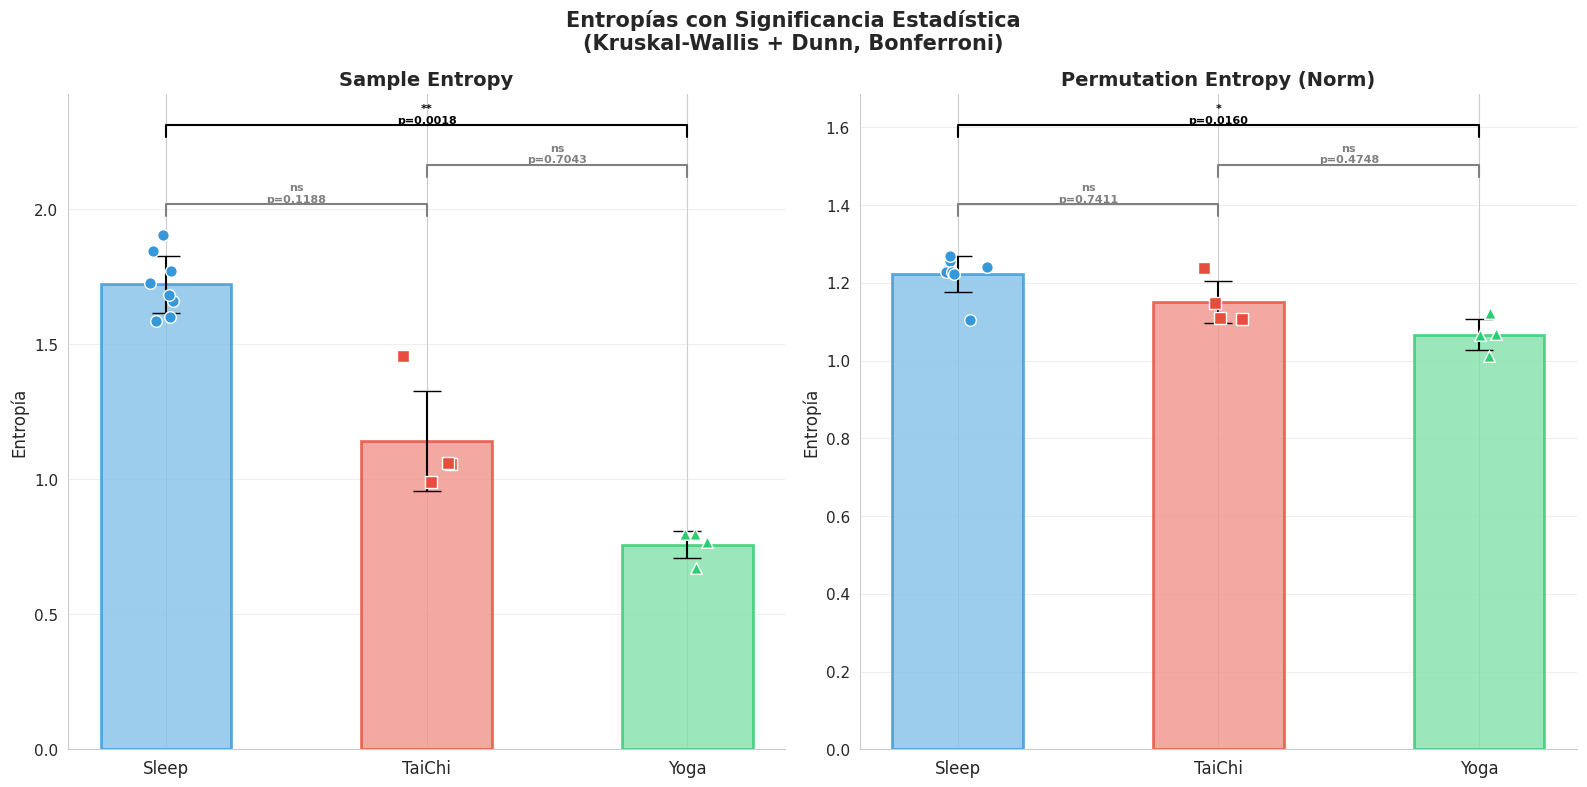

✅ Figura guardada: 08_barras_significancia.png


In [ ]:
# =============================================================================
# CELDA 19: BARRAS CON SIGNIFICANCIA ESTADÍSTICA
# =============================================================================

def add_significance_bar(ax, x1, x2, y, p_val, h=0.02):
    """Dibuja una barra de significancia entre dos posiciones."""
    if p_val < 0.001: sig = '***'
    elif p_val < 0.01: sig = '**'
    elif p_val < 0.05: sig = '*'
    else: sig = 'ns'

    color = 'black' if p_val < ALPHA else 'gray'

    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color=color, linewidth=1.5)
    ax.text((x1+x2)/2, y+h, f'{sig}\np={p_val:.4f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color=color)

# -------

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Entropías con Significancia Estadística\n'
             '(Kruskal-Wallis + Dunn, Bonferroni)',
             fontsize=15, fontweight='bold')

plot_configs = [
    ('SampEn', 'Sample Entropy', 'Sample Entropy'),
    ('PermEn_norm', 'Permutation Entropy (Norm)', 'Permutation Entropy (Norm)')
]

colors = [GROUPS[g]['color'] for g in GROUP_ORDER]
colors_l = [GROUPS[g]['color_light'] for g in GROUP_ORDER]

for plot_idx, (col, dunn_name, title) in enumerate(plot_configs):
    ax = axes[plot_idx]

    means, stds = [], []
    for g in GROUP_ORDER:
        vals = df_combined[df_combined['Grupo']==g][col].dropna().values
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    x = np.arange(len(GROUP_ORDER))
    ax.bar(x, means, yerr=stds, color=colors_l, edgecolor=colors,
           linewidth=2, capsize=10, alpha=0.8, width=0.5)

    # Puntos individuales
    for i, g in enumerate(GROUP_ORDER):
        vals = df_combined[df_combined['Grupo']==g][col].dropna().values
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(x[i]+jitter, vals, color=colors[i], s=70, zorder=5,
                   edgecolors='white', linewidth=1, marker=GROUPS[g]['marker'])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(GROUP_ORDER, fontsize=12)
    ax.set_ylabel('Entropía', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Barras de significancia
    y_max = max(m + s for m, s in zip(means, stds))
    y_step = y_max * 0.08

    # Obtener p-valores del test de Dunn para esta medida
    mat = dunn_matrices[col]
    pairs_pos = [(0, 1), (1, 2), (0, 2)]  # Sleep-TaiChi, TaiChi-Yoga, Sleep-Yoga
    pairs_names = [('Sleep','TaiChi'), ('TaiChi','Yoga'), ('Sleep','Yoga')]

    for k, ((xi, xj), (g1, g2)) in enumerate(zip(pairs_pos, pairs_names)):
        p = mat.loc[g1, g2]
        y_bar = y_max + y_step * (k + 1)
        add_significance_bar(ax, xi, xj, y_bar, p, h=y_step*0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '08_barras_significancia.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 08_barras_significancia.png")

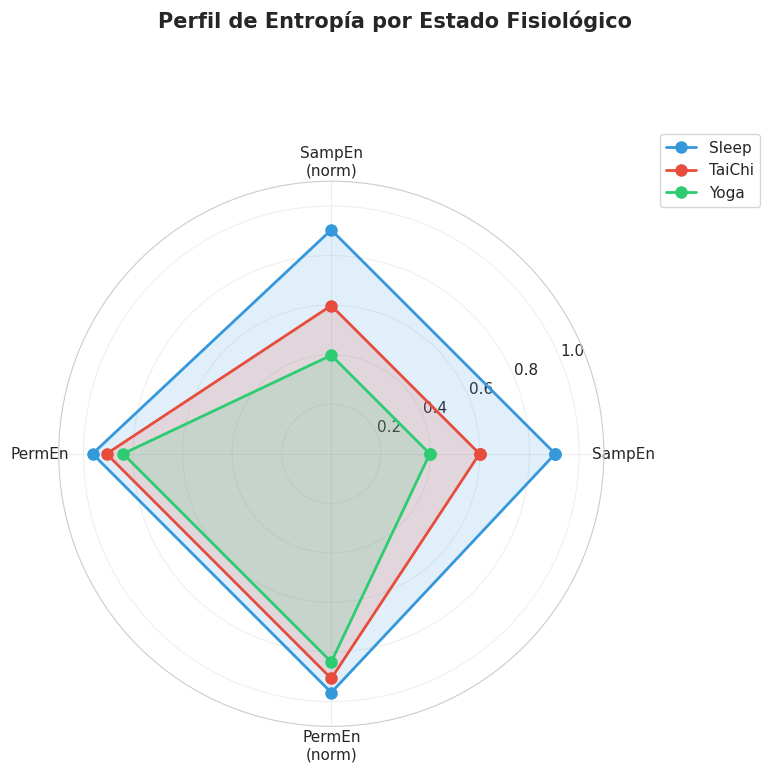

✅ Figura guardada: 09_radar_entropia.png


In [ ]:
# =============================================================================
# CELDA 20: GRÁFICA RADAR - PERFIL DE ENTROPÍA
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('Perfil de Entropía por Estado Fisiológico',
             fontsize=15, fontweight='bold', y=1.02)

categories = ['SampEn', 'SampEn\n(norm)', 'PermEn', 'PermEn\n(norm)']
cols = ['SampEn', 'SampEn_norm', 'PermEn', 'PermEn_norm']
N = len(categories)

# Ángulos
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for group in GROUP_ORDER:
    gd = df_combined[df_combined['Grupo'] == group]
    values = [gd[c].mean() for c in cols]

    # Normalizar al máximo global de cada medida para que sea comparable
    values_norm = []
    for c, v in zip(cols, values):
        max_val = df_combined[c].max()
        values_norm.append(v / max_val if max_val > 0 else 0)

    values_norm += values_norm[:1]

    ax.plot(angles, values_norm, 'o-', linewidth=2,
            color=GROUPS[group]['color'], label=group, markersize=8)
    ax.fill(angles, values_norm, alpha=0.15, color=GROUPS[group]['color'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'figuras', '09_radar_entropia.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 09_radar_entropia.png")

In [ ]:
# =============================================================================
# CELDA 21: RESUMEN EJECUTIVO E INTERPRETACIÓN
# =============================================================================

print("=" * 70)
print("  RESUMEN EJECUTIVO - ANÁLISIS DE ENTROPÍA ECG")
print("=" * 70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    CONTEXTO DEL ESTUDIO                             ║
╠══════════════════════════════════════════════════════════════════════╣
║ • Señales ECG (intervalos RR latido a latido)                       ║
║ • 3 estados fisiológicos:                                           ║
║   - Sueño: estado inconsciente (n=8)                                ║
║   - Tai Chi: consciente, respiración controlada (n=4)               ║
║   - Yoga Kundalini: consciente, respiración controlada (n=4)        ║
║ • Medidas: Sample Entropy (SampEn) y Permutation Entropy (PermEn)  ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# --- Resultados por medida ---
print("─" * 70)
print("📊 RESULTADOS DE ENTROPÍA POR GRUPO:")
print("─" * 70)

for col, name in [('SampEn', 'Sample Entropy'), ('PermEn_norm', 'Perm Entropy (norm)')]:
    print(f"\n  {name}:")
    for g in GROUP_ORDER:
        vals = df_combined[df_combined['Grupo']==g][col].dropna().values
        print(f"    {g:8s}: {np.mean(vals):.6f} ± {np.std(vals):.6f} "
              f"(mediana: {np.median(vals):.6f})")

# --- Kruskal-Wallis ---
print("\n" + "─" * 70)
print("📊 KRUSKAL-WALLIS:")
print("─" * 70)
for _, row in df_kw.iterrows():
    sig = "✅ SIG" if row['Significativo'] else "❌ NS"
    print(f"  {row['Medida']:35s}: H={row['H']:.4f}, p={row['p_valor']:.6f}, "
          f"η²={row['eta_cuadrado']:.4f} ({row['Tamaño_efecto']}) {sig}")

# --- Dunn ---
print("\n" + "─" * 70)
print("📊 DUNN POST HOC (Bonferroni):")
print("─" * 70)
for _, row in df_dunn.iterrows():
    sig = "✅" if row['Significativo'] else "❌"
    print(f"  {row['Medida']:35s} | {row['Comparación']:20s}: "
          f"p={row['p_valor']:.6f} {sig}")

# --- Interpretación ---
print("\n" + "=" * 70)
print("📝 INTERPRETACIÓN FISIOLÓGICA:")
print("=" * 70)

print("""
1. SAMPLE ENTROPY (SampEn):
   - Mide la irregularidad/complejidad de los intervalos RR.
   - Valores ALTOS → mayor variabilidad e irregularidad cardíaca.
   - Valores BAJOS → ritmo cardíaco más regular y predecible.

2. PERMUTATION ENTROPY (PermEn):
   - Mide la complejidad basada en patrones ordinales.
   - Valores cercanos a 1 → alta complejidad/aleatoriedad.
   - Valores cercanos a 0 → alta regularidad.

3. SUEÑO vs ACTIVIDADES CONSCIENTES:
   - Durante el sueño, el sistema nervioso autónomo opera en modo
     parasimpático, lo que puede generar patrones característicos
     de variabilidad cardíaca.
   - Tai Chi y Yoga Kundalini implican respiración controlada,
     lo que modula el tono vagal y puede alterar la complejidad
     de la dinámica cardíaca.

4. YOGA KUNDALINI vs TAI CHI:
   - Ambas son actividades conscientes con respiración controlada,
     pero Yoga Kundalini enfatiza técnicas específicas de pranayama
     (control respiratorio) que pueden producir patrones distintos
     de acoplamiento cardiorrespiratorio.

5. SIGNIFICANCIA CLÍNICA:
   - Las diferencias en entropía reflejan cambios en la regulación
     autonómica del corazón según el estado fisiológico.
   - Mayor entropía → mayor complejidad adaptativa del sistema
     cardiovascular (generalmente indicador de salud).
""")

# --- Archivos generados ---
print("=" * 70)
print("📁 ARCHIVOS GENERADOS:")
print("=" * 70)

print("\n  📊 Tablas (CSV):")
for f in os.listdir(os.path.join(RESULTS_PATH, 'tablas')):
    print(f"     • {f}")

print("\n  🖼️ Figuras (PNG):")
for f in sorted(os.listdir(os.path.join(RESULTS_PATH, 'figuras'))):
    print(f"     • {f}")

print("\n" + "=" * 70)
print("  ✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

  RESUMEN EJECUTIVO - ANÁLISIS DE ENTROPÍA ECG

╔══════════════════════════════════════════════════════════════════════╗
║                    CONTEXTO DEL ESTUDIO                             ║
╠══════════════════════════════════════════════════════════════════════╣
║ • Señales ECG (intervalos RR latido a latido)                       ║
║ • 3 estados fisiológicos:                                           ║
║   - Sueño: estado inconsciente (n=8)                                ║
║   - Tai Chi: consciente, respiración controlada (n=4)               ║
║   - Yoga Kundalini: consciente, respiración controlada (n=4)        ║
║ • Medidas: Sample Entropy (SampEn) y Permutation Entropy (PermEn)  ║
╚══════════════════════════════════════════════════════════════════════╝

──────────────────────────────────────────────────────────────────────
📊 RESULTADOS DE ENTROPÍA POR GRUPO:
──────────────────────────────────────────────────────────────────────

  Sample Entropy:
    Sleep   : 1.721879 ± 0.10602